### This notebook compute "P12. Distance from the glacier to the lagoon" indicator for the 27 basins of IKI Project

Spanish: Distancia del glaciar a la laguna

**Created:** 6/23/2025 by Jorge Mayo (jmayo@rti.org)  / Serena Gilson

**Inputs:**   MAPA_NACIONAL_DE_ECOSISTEMAS_2012-2018 (MINAM), INAIGEM inventario de glaciares 2020, https://geocatmin.ingemmet.gob.pe/geocatmin/ 
 
**Assumptions:** COMIDs without a glacier are assigned NaN so the indicator is not included in the calculation.

**N/A Handling:** Classification scheme sets any subbasins with no distance to glaciers > 3000 m to 0.
 
 We will need to make changes in this script if we get a future glaciers shapefile.
 
**Notes:** 
1. Generate multiple glacier shapefiles using different buffer distances; 5 m, 100 m, 500 m, 3000 m.  
2. Intersect each buffered shapefile with the subbasins shapefile to calculate the total area of each buffer file within each COMID.  
3. Merge all files so dataframe has one colume for each buffer zone.  
4. Classify the distance values: Default is 0 and gets overwritten with 1 for subbasins that intersected with the 5 m buffer, 0.75 for subbasins that intersected with the 100 m buffer, 0.5 for subbasins that intersected with the 500 m buffer; and 0.25 for subbasins that intersected with the 3000 m buffer.  

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import rasterio
import yaml
from pathlib import Path

In [2]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [3]:
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
glaciares = master_path / "Indicadores" / "Datos_INAIGEM" / "Glaciares_2020_COMID_v2.shp"
glaciares_futuro = master_path / "Indicadores" / "Datos_INAIGEM" / "glaciares_2050_SSP585.shp"

In [4]:
# set up indicator ID and get scenarios from database
IndID= 112 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
scenario_glacier_config = {
    1: {"use_future_glaciers": False},
    2: {"use_future_glaciers": True},
    3: {"use_future_glaciers": True},
}

In [6]:
# Load the shapefiles
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
glaciares_actual_gdf = gpd.read_file(glaciares).to_crs("EPSG:32718")
glaciares_futuro_gdf = gpd.read_file(glaciares_futuro).to_crs("EPSG:32718")


In [7]:
def calculate_glacier_buffer_score(subbasins_gdf, glaciers_gdf, value_col_name):
    """
    Calculate glacier proximity/buffer score by COMID.

    1.0  = intersects 5 m glacier buffer
    0.75 = intersects 100 m buffer only
    0.50 = intersects 500 m buffer only
    0.25 = intersects 3000 m buffer only
    NaN  = no glacier buffer intersection
    """

    glaciers_gdf = glaciers_gdf.copy().to_crs(subbasins_gdf.crs)

    buffer_5m_gdf = gpd.GeoDataFrame(
        geometry=glaciers_gdf.buffer(5),
        crs=glaciers_gdf.crs
    )

    buffer_100m_gdf = gpd.GeoDataFrame(
        geometry=glaciers_gdf.buffer(100),
        crs=glaciers_gdf.crs
    )

    buffer_500m_gdf = gpd.GeoDataFrame(
        geometry=glaciers_gdf.buffer(500),
        crs=glaciers_gdf.crs
    )

    buffer_3000m_gdf = gpd.GeoDataFrame(
        geometry=glaciers_gdf.buffer(3000),
        crs=glaciers_gdf.crs
    )

    intersect_5m = gpd.overlay(buffer_5m_gdf, subbasins_gdf, how="intersection")
    intersect_100m = gpd.overlay(buffer_100m_gdf, subbasins_gdf, how="intersection")
    intersect_500m = gpd.overlay(buffer_500m_gdf, subbasins_gdf, how="intersection")
    intersect_3000m = gpd.overlay(buffer_3000m_gdf, subbasins_gdf, how="intersection")

    intersect_5m["area_5m"] = intersect_5m.geometry.area
    intersect_100m["area_100m"] = intersect_100m.geometry.area
    intersect_500m["area_500m"] = intersect_500m.geometry.area
    intersect_3000m["area_3000m"] = intersect_3000m.geometry.area

    area_5m_df = (
        intersect_5m
        .groupby("COMID")["area_5m"]
        .sum()
        .reset_index()
    )

    area_100m_df = (
        intersect_100m
        .groupby("COMID")["area_100m"]
        .sum()
        .reset_index()
    )

    area_500m_df = (
        intersect_500m
        .groupby("COMID")["area_500m"]
        .sum()
        .reset_index()
    )

    area_3000m_df = (
        intersect_3000m
        .groupby("COMID")["area_3000m"]
        .sum()
        .reset_index()
    )

    final_df = (
        area_5m_df
        .merge(area_100m_df, on="COMID", how="outer")
        .merge(area_500m_df, on="COMID", how="outer")
        .merge(area_3000m_df, on="COMID", how="outer")
    )

    final_df[value_col_name] = np.nan

    final_df.loc[
        final_df["area_5m"].notna(),
        value_col_name
    ] = 1

    final_df.loc[
        final_df["area_5m"].isna()
        & final_df["area_100m"].notna(),
        value_col_name
    ] = 0.75

    final_df.loc[
        final_df["area_5m"].isna()
        & final_df["area_100m"].isna()
        & final_df["area_500m"].notna(),
        value_col_name
    ] = 0.5

    final_df.loc[
        final_df["area_5m"].isna()
        & final_df["area_100m"].isna()
        & final_df["area_500m"].isna()
        & final_df["area_3000m"].notna(),
        value_col_name
    ] = 0.25

    return final_df[
        [
            "COMID",
            "area_5m",
            "area_100m",
            "area_500m",
            "area_3000m",
            value_col_name
        ]
    ]

In [8]:
# Baseline values from 2020 glaciers
baseline_buffer_df = calculate_glacier_buffer_score(
    subbasins_gdf=subbasins_gdf,
    glaciers_gdf=glaciares_actual_gdf,
    value_col_name="Baseline_value"
)

# Future values from projected glaciers
future_buffer_df = calculate_glacier_buffer_score(
    subbasins_gdf=subbasins_gdf,
    glaciers_gdf=glaciares_futuro_gdf,
    value_col_name="Future_value"
)

In [9]:
# Merge values back to subbasins
subbasins_with_buffers = subbasins_gdf.merge(
    baseline_buffer_df[
        [
            "COMID",
            "Baseline_value"
        ]
    ],
    on="COMID",
    how="left"
)

subbasins_with_buffers = subbasins_with_buffers.merge(
    future_buffer_df[
        [
            "COMID",
            "Future_value"
        ]
    ],
    on="COMID",
    how="left"
)

future_projection_comids = set(
    glaciares_futuro_gdf["COMID"]
    .dropna()
    .unique()
)

subbasins_with_buffers["Has_Future_Projection"] = (
    subbasins_with_buffers["COMID"].isin(future_projection_comids)
)

print("Baseline buffer score distribution:")
print(
    subbasins_with_buffers["Baseline_value"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nFuture buffer score distribution:")
print(
    subbasins_with_buffers["Future_value"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nCOMIDs with future glacier projection:")
print(subbasins_with_buffers["Has_Future_Projection"].sum())


Baseline buffer score distribution:
Baseline_value
0.25      50
0.50      20
0.75       4
1.00     289
NaN     3292
Name: count, dtype: int64

Future buffer score distribution:
Future_value
0.25       9
0.50       5
0.75       1
1.00      53
NaN     3587
Name: count, dtype: int64

COMIDs with future glacier projection:
52


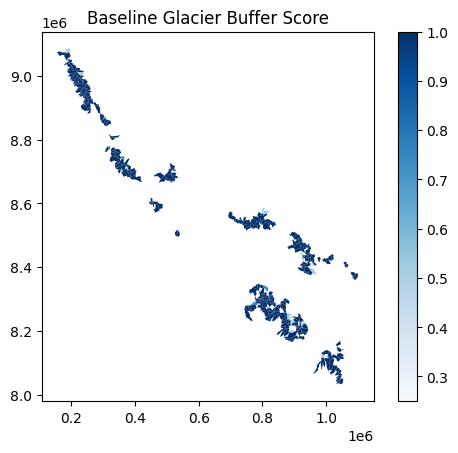

In [11]:
# Optional plot
subbasins_with_buffers.plot(
    column="Baseline_value",
    cmap="Blues",
    legend=True
)

plt.title("Baseline Glacier Buffer Score")
plt.show()

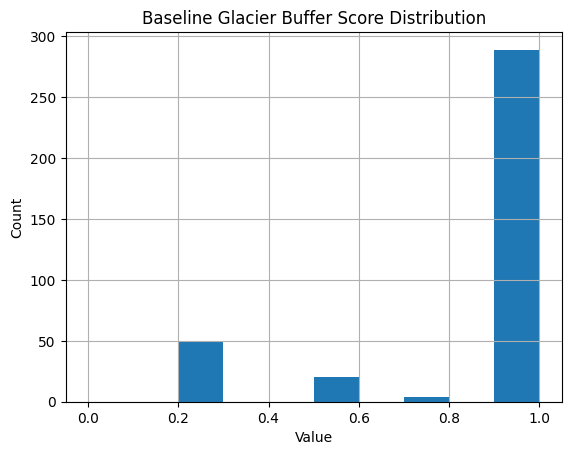

In [10]:
# Optional histogram
subbasins_with_buffers["Baseline_value"].hist(
    bins=10,
    range=(0, 1)
)

plt.title("Baseline Glacier Buffer Score Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


In [12]:
# sqlite insert
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for scn_id in scenario_ids:

    cfg = scenario_glacier_config.get(
        scn_id,
        {"use_future_glaciers": False}
    )

    scenario_df = subbasins_with_buffers.copy()

    # Start every scenario with baseline values
    scenario_df["Value"] = scenario_df["Baseline_value"]

    if cfg["use_future_glaciers"]:

        # Only overwrite COMIDs that exist in the future glacier projection
        mask_future_projected = scenario_df["Has_Future_Projection"]

        scenario_df.loc[
            mask_future_projected,
            "Value"
        ] = scenario_df.loc[
            mask_future_projected,
            "Future_value"
        ]

    for _, row in scenario_df.iterrows():

        rows_to_insert.append((
            scn_id,
            IndID,
            int(row["COMID"]),
            None if pd.isna(row["Value"]) else float(row["Value"])
        ))

insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [13]:
# Check indicator limits and scenario stats
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, "Min"]
ind_max = indicator_limits.loc[0, "Max"]

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

df_check = pd.DataFrame(
    rows_to_insert,
    columns=["ScnID", "IndID", "COMID", "Value"]
)

value_stats_by_scenario = (
    df_check
    .groupby("ScnID")["Value"]
    .agg(["min", "max", "count"])
    .reset_index()
    .merge(scenarios_df, on="ScnID", how="left")
)

value_stats_by_scenario["Indicator_Min"] = ind_min
value_stats_by_scenario["Indicator_Max"] = ind_max

print("\n=== Values to be inserted by scenario ===")
print(
    value_stats_by_scenario[
        [
            "ScnID",
            "ScnName",
            "min",
            "max",
            "count",
            "Indicator_Min",
            "Indicator_Max"
        ]
    ]
)

duplicates = df_check.duplicated(
    subset=["ScnID", "IndID", "COMID"]
)

print("\nDuplicates in rows_to_insert:")
print(df_check[duplicates])


Indicator 112  Min: 0.25, Max: 1

=== Values to be inserted by scenario ===
   ScnID      ScnName   min  max  count  Indicator_Min  Indicator_Max
0      1   Linea Base  0.25  1.0    363           0.25              1
1      2  CC CMIP6 85  0.25  1.0    363           0.25              1
2      3  CC CMIP6 45  0.25  1.0    363           0.25              1

Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [14]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()